# Machine Learning — Notebook 08
## Random Forest: ensamble, importancias y estabilidad

### Objetivos
- Entender por qué un **ensamble de árboles** es mejor que un árbol solo.
- Aprender los dos mecanismos clave de Random Forest: **bagging** y **subespacio aleatorio de features**.
- Usar el **error OOB** como estimación interna del error de generalización.
- Comparar **RF vs árbol único** en rendimiento y estabilidad.
- Entender y visualizar **feature importance** (MDI) en RF.
- Ver cómo RF es robusto al cambio de semilla (baja varianza), a diferencia del árbol solo.

### Ideas clave
- Un árbol tiene alta varianza: cambia mucho si cambian los datos.
- RF entrena $B$ árboles sobre **muestras bootstrap** y promedia → reduce varianza sin aumentar sesgo.
- En cada split solo se considera un **subconjunto aleatorio de $m$ features** (decorrelación entre árboles).
- Con $m = \sqrt{p}$ (clasificación) o $m = p/3$ (regresión) suele funcionar bien.
- El **OOB error** usa las muestras que no entraron en cada árbol → estimación gratuita de test error.

> Trabajaremos con datos simulados para el análisis teórico, y con un dataset tabular para la comparación práctica.

---
## 0) Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.datasets import make_classification
from sklearn.inspection import permutation_importance

RANDOM_STATE = 7
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 200)

---
## 1) Filosofía del ensamble: ¿por qué funciona?

La intuición central es el **trade-off sesgo-varianza**:

$$
\text{Error} = \text{Sesgo}^2 + \text{Varianza} + \text{Ruido irreducible}
$$

Un árbol profundo tiene bajo sesgo pero alta varianza.  
Si promediamos $B$ árboles **independientes** con varianza $\sigma^2$, la varianza del promedio es:

$$
\text{Var}(\bar{T}) = \frac{\sigma^2}{B}
$$

Pero los árboles sobre el mismo dataset **no son independientes** (correlación $\rho$). En la práctica:

$$
\text{Var}(\bar{T}) = \rho\,\sigma^2 + \frac{1-\rho}{B}\,\sigma^2
$$

Random Forest reduce $\rho$ mediante el **subespacio aleatorio de features** → sigue bajando la varianza aunque $B$ sea grande.

In [2]:
# 1.1 Demostración numérica: un árbol vs promedio de árboles
# Entrenamos 50 árboles individuales con distintos random_state
# y comparamos sus predicciones con un RF de 50 árboles

X, y = make_classification(
    n_samples=1500, n_features=10, n_informative=5,
    n_redundant=2, weights=[0.65, 0.35],
    class_sep=0.9, flip_y=0.04, random_state=RANDOM_STATE
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# Árbol único con distintas semillas → alta varianza
single_accs = []
for seed in range(50):
    dt = DecisionTreeClassifier(random_state=seed)
    dt.fit(X_train, y_train)
    single_accs.append(accuracy_score(y_test, dt.predict(X_test)))

# RF con distintas semillas → baja varianza
rf_accs = []
for seed in range(50):
    rf = RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_accs.append(accuracy_score(y_test, rf.predict(X_test)))

print(f"Árbol único — media: {np.mean(single_accs):.4f} | std: {np.std(single_accs):.4f}")
print(f"RF (100 árboles) — media: {np.mean(rf_accs):.4f} | std: {np.std(rf_accs):.4f}")

Árbol único — media: 0.8006 | std: 0.0095
RF (100 árboles) — media: 0.8900 | std: 0.0062


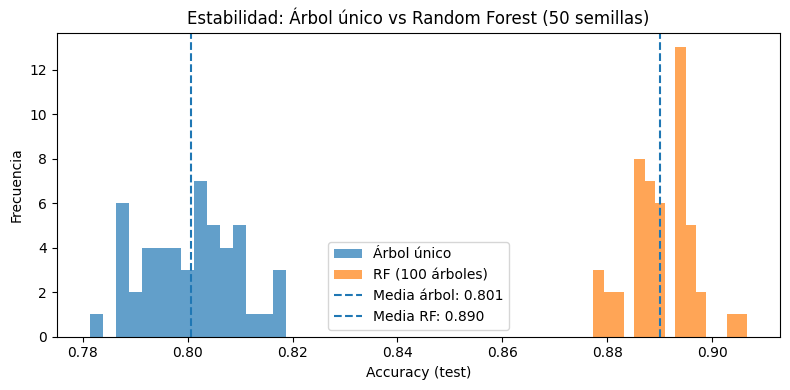

In [3]:
# 1.2 Visualizar la distribución de accuracies
plt.figure(figsize=(8, 4))
plt.hist(single_accs, bins=15, alpha=0.7, label="Árbol único")
plt.hist(rf_accs,     bins=15, alpha=0.7, label="RF (100 árboles)")
plt.axvline(np.mean(single_accs), linestyle="--", label=f"Media árbol: {np.mean(single_accs):.3f}")
plt.axvline(np.mean(rf_accs),     linestyle="--", label=f"Media RF: {np.mean(rf_accs):.3f}")
plt.xlabel("Accuracy (test)")
plt.ylabel("Frecuencia")
plt.title("Estabilidad: Árbol único vs Random Forest (50 semillas)")
plt.legend()
plt.tight_layout()
plt.show()

---
## 2) Bagging y el parámetro `n_estimators`

**Bagging** (Bootstrap AGGregatING):
1. Para cada árbol $b = 1, \ldots, B$: extraer una muestra bootstrap de tamaño $n$ (con reemplazo).
2. Entrenar un árbol completo sobre esa muestra.
3. Predicción final: **voto de mayoría** (clasificación) o **promedio** (regresión).

¿Cuántos árboles necesitamos? El error baja rápido al principio y luego se estabiliza.

/opt/homebrew/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


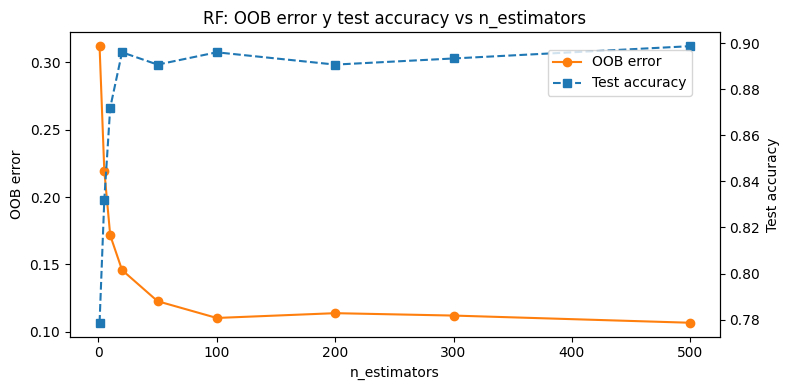

In [4]:
# 2.1 Curva de error vs n_estimators
n_trees = [1, 5, 10, 20, 50, 100, 200, 300, 500]
oob_errors = []
test_accs   = []

for n in n_trees:
    rf = RandomForestClassifier(
        n_estimators=n, oob_score=True,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    rf.fit(X_train, y_train)
    oob_errors.append(1 - rf.oob_score_)
    test_accs.append(accuracy_score(y_test, rf.predict(X_test)))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(n_trees, oob_errors, marker="o", label="OOB error", color="tab:orange")
ax1.set_xlabel("n_estimators")
ax1.set_ylabel("OOB error")
ax2 = ax1.twinx()
ax2.plot(n_trees, test_accs, marker="s", linestyle="--", label="Test accuracy", color="tab:blue")
ax2.set_ylabel("Test accuracy")
ax1.set_title("RF: OOB error y test accuracy vs n_estimators")
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

In [5]:
# 2.2 ¿Qué es el OOB error?
# Cada árbol se entrena con ~63% de los datos; el 37% restante ("out of bag")
# se usa como validación interna → estimación del error sin necesidad de test split

rf_oob = RandomForestClassifier(
    n_estimators=200, oob_score=True,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_oob.fit(X_train, y_train)

print(f"OOB score (accuracy): {rf_oob.oob_score_:.4f}")
print(f"Test accuracy:        {accuracy_score(y_test, rf_oob.predict(X_test)):.4f}")
print("→ OOB es una estimación gratuita del error de generalización.")

OOB score (accuracy): 0.8862
Test accuracy:        0.8907
→ OOB es una estimación gratuita del error de generalización.


---
## 3) RF vs Árbol único: comparación directa

Usamos un **dataset tabular con más features** para comparar en condiciones realistas:  
árbol sin restricción, árbol con mejor `max_depth` (CV), y RF con CV.

In [6]:
# 3.1 Dataset tabular simulado
X_tab, y_tab = make_classification(
    n_samples=2500, n_features=15, n_informative=7,
    n_redundant=4, weights=[0.70, 0.30],
    class_sep=0.95, flip_y=0.04, random_state=RANDOM_STATE
)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_tab, y_tab, test_size=0.25, random_state=RANDOM_STATE, stratify=y_tab
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Train size:", X_tr.shape, "| Class balance:", pd.Series(y_tr).value_counts(normalize=True).round(3).to_dict())

Train size: (1875, 15) | Class balance: {0: 0.692, 1: 0.308}


In [7]:
# 3.2 Seleccionar mejor max_depth para el árbol con CV
depth_grid = [2, 3, 4, 5, 6, 8, 10, None]
dt_cv_scores = {}

for d in depth_grid:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    scores = cross_val_score(dt, X_tr, y_tr, cv=cv, scoring="f1")
    dt_cv_scores[str(d)] = scores.mean()

best_depth = max(dt_cv_scores, key=dt_cv_scores.get)
best_depth_val = None if best_depth == "None" else int(best_depth)
print(f"Mejor max_depth (CV): {best_depth} — F1: {dt_cv_scores[best_depth]:.4f}")

Mejor max_depth (CV): 8 — F1: 0.6593


In [8]:
# 3.3 Entrenar los tres modelos y comparar en test
dt_free  = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_tuned = DecisionTreeClassifier(max_depth=best_depth_val, random_state=RANDOM_STATE)
rf_model = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=RANDOM_STATE, n_jobs=-1)
dummy    = DummyClassifier(strategy="most_frequent")

models = {
    "Baseline": dummy,
    "Árbol sin restricción": dt_free,
    f"Árbol (max_depth={best_depth})": dt_tuned,
    "RandomForest (200)": rf_model,
}

def clf_report(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred  = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    return {
        "Modelo": name,
        "Acc_train": accuracy_score(y_train, model.predict(X_train)),
        "Accuracy":  accuracy_score(y_test, pred),
        "BalancedAcc": balanced_accuracy_score(y_test, pred),
        "F1":       f1_score(y_test, pred, zero_division=0),
        "ROC_AUC":  roc_auc_score(y_test, proba),
        "PR_AUC":   average_precision_score(y_test, proba),
    }

rows = [clf_report(name, m, X_tr, y_tr, X_te, y_te) for name, m in models.items()]
df_cmp = pd.DataFrame(rows).set_index("Modelo").round(4)
df_cmp

,Acc_train,Accuracy,BalancedAcc,F1,ROC_AUC,PR_AUC
Modelo,,,,,,
Baseline,0.6923,0.6912,0.5000,0.0000,0.5000,0.3088
Árbol sin restricción,1.0000,0.7696,0.7344,0.6327,0.7344,0.5107
Árbol (max_depth=8),0.9275,0.8160,0.7723,0.6883,0.8117,0.6412
RandomForest (200),1.0000,0.8688,0.8306,0.7747,0.9416,0.8887


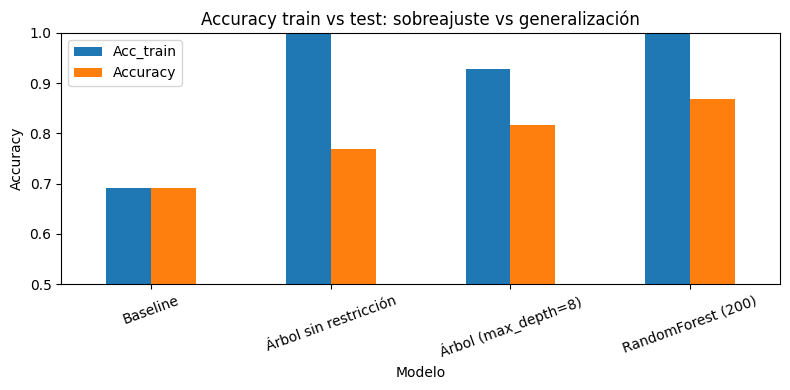

In [9]:
# 3.4 La brecha train-test revela el sobreajuste del árbol sin restricción
df_cmp[["Acc_train", "Accuracy"]].plot(
    kind="bar", figsize=(8, 4), ylim=(0.5, 1.0), rot=20
)
plt.ylabel("Accuracy")
plt.title("Accuracy train vs test: sobreajuste vs generalización")
plt.tight_layout()
plt.show()

---
## 4) Feature Importance en Random Forest

### 4a) MDI — Mean Decrease in Impurity
Promedio de la reducción de Gini en todos los splits de todos los árboles que usan la feature $j$.

$$
\text{MDI}(j) = \frac{1}{B} \sum_{b=1}^{B} \sum_{t: \text{split en }j} \frac{n_t}{n} \cdot \Delta\text{impureza}(t)
$$

**Ventaja:** rápido de calcular (ya disponible en el objeto entrenado).  
**Limitación:** sobreestima features con muchos valores únicos (alta cardinalidad).

### 4b) Permutation Importance
Para cada feature $j$: barajar aleatoriamente sus valores en el test → medir cuánto cae la métrica.  
Más robusto, pero computacionalmente más costoso.

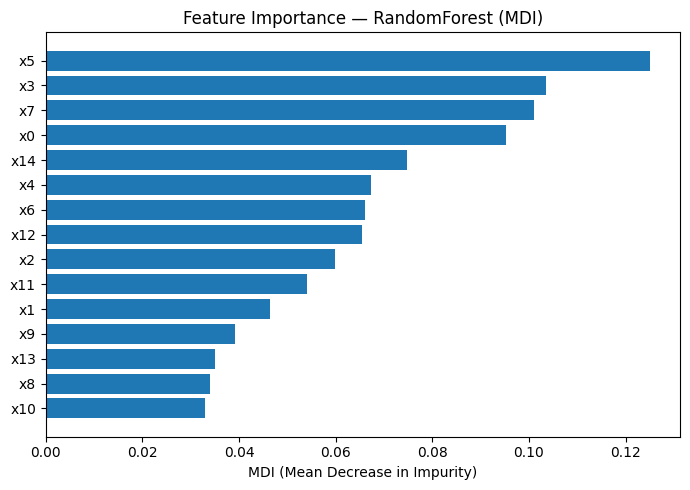

In [10]:
# 4.1 MDI (ya calculada al entrenar)
feat_names = [f"x{i}" for i in range(X_tr.shape[1])]

df_mdi = pd.DataFrame({
    "feature": feat_names,
    "MDI": rf_model.feature_importances_
}).sort_values("MDI", ascending=True)

plt.figure(figsize=(7, 5))
plt.barh(df_mdi["feature"], df_mdi["MDI"])
plt.xlabel("MDI (Mean Decrease in Impurity)")
plt.title("Feature Importance — RandomForest (MDI)")
plt.tight_layout()
plt.show()

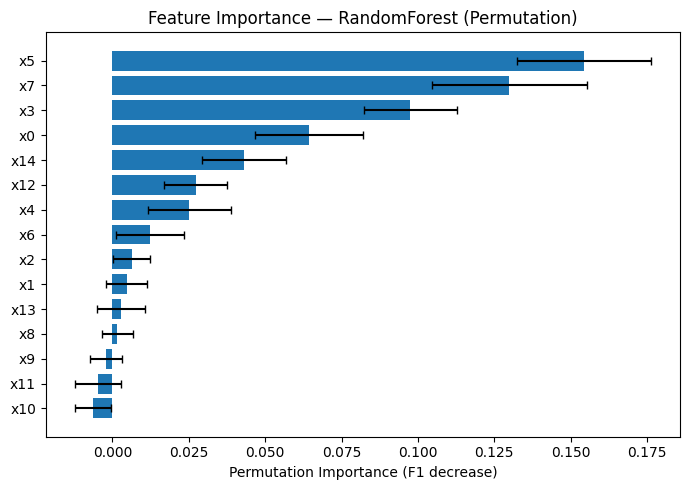

In [11]:
# 4.2 Permutation Importance (sobre test)
perm = permutation_importance(
    rf_model, X_te, y_te,
    n_repeats=15, random_state=RANDOM_STATE, scoring="f1"
)

df_perm = pd.DataFrame({
    "feature": feat_names,
    "Perm_mean": perm.importances_mean,
    "Perm_std":  perm.importances_std
}).sort_values("Perm_mean", ascending=True)

plt.figure(figsize=(7, 5))
plt.barh(df_perm["feature"], df_perm["Perm_mean"],
         xerr=df_perm["Perm_std"], capsize=3)
plt.xlabel("Permutation Importance (F1 decrease)")
plt.title("Feature Importance — RandomForest (Permutation)")
plt.tight_layout()
plt.show()

In [12]:
# 4.3 Comparar rankings MDI vs Permutation
df_mdi_rank  = df_mdi.sort_values("MDI", ascending=False).reset_index(drop=True)
df_perm_rank = df_perm.sort_values("Perm_mean", ascending=False).reset_index(drop=True)

rank_compare = pd.DataFrame({
    "Rank": range(1, len(feat_names)+1),
    "MDI_feature":  df_mdi_rank["feature"].values,
    "Perm_feature": df_perm_rank["feature"].values
})
rank_compare

,Rank,MDI_feature,Perm_feature
0,1,x5,x5
1,2,x3,x7
2,3,x7,x3
3,4,x0,x0
4,5,x14,x14
5,6,x4,x12
6,7,x6,x4
7,8,x12,x6
8,9,x2,x2
9,10,x11,x1


---
## 5) Estabilidad: RF vs árbol por semillas

Entrenamos el mismo modelo 30 veces cambiando solo `random_state`.  
Un modelo estable tiene baja **desviación estándar** en sus métricas de test.

In [13]:
# 5.1 Variabilidad en test accuracy según la semilla
n_seeds = 30
seeds = range(n_seeds)

accs_dt  = []
accs_rf  = []
f1s_dt   = []
f1s_rf   = []

for s in seeds:
    # Árbol tuneado
    dt = DecisionTreeClassifier(max_depth=best_depth_val, random_state=s)
    dt.fit(X_tr, y_tr)
    accs_dt.append(accuracy_score(y_te, dt.predict(X_te)))
    f1s_dt.append(f1_score(y_te, dt.predict(X_te), zero_division=0))

    # RF
    rf = RandomForestClassifier(n_estimators=150, random_state=s, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    accs_rf.append(accuracy_score(y_te, rf.predict(X_te)))
    f1s_rf.append(f1_score(y_te, rf.predict(X_te), zero_division=0))

print("Accuracy — media ± std")
print(f"  Árbol (max_depth={best_depth}): {np.mean(accs_dt):.4f} ± {np.std(accs_dt):.4f}")
print(f"  Random Forest (150):           {np.mean(accs_rf):.4f} ± {np.std(accs_rf):.4f}")
print()
print("F1 — media ± std")
print(f"  Árbol (max_depth={best_depth}): {np.mean(f1s_dt):.4f} ± {np.std(f1s_dt):.4f}")
print(f"  Random Forest (150):           {np.mean(f1s_rf):.4f} ± {np.std(f1s_rf):.4f}")

Accuracy — media ± std
  Árbol (max_depth=8): 0.8203 ± 0.0025
  Random Forest (150):           0.8708 ± 0.0047

F1 — media ± std
  Árbol (max_depth=8): 0.6954 ± 0.0038
  Random Forest (150):           0.7796 ± 0.0087


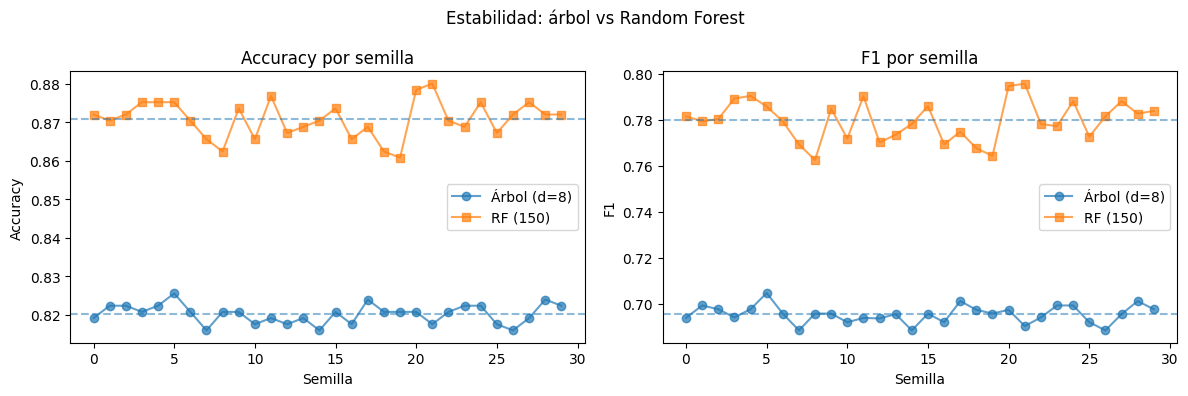

In [14]:
# 5.2 Visualizar variabilidad a lo largo de las semillas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (metric_dt, metric_rf, title) in zip(
    axes,
    [(accs_dt, accs_rf, "Accuracy"), (f1s_dt, f1s_rf, "F1")]
):
    ax.plot(seeds, metric_dt, marker="o", alpha=0.7, label=f"Árbol (d={best_depth})")
    ax.plot(seeds, metric_rf, marker="s", alpha=0.7, label="RF (150)")
    ax.axhline(np.mean(metric_dt), linestyle="--", alpha=0.5)
    ax.axhline(np.mean(metric_rf), linestyle="--", alpha=0.5)
    ax.set_xlabel("Semilla")
    ax.set_ylabel(title)
    ax.set_title(f"{title} por semilla")
    ax.legend()

plt.suptitle("Estabilidad: árbol vs Random Forest")
plt.tight_layout()
plt.show()

---
## 6) Hiperparámetros clave de RandomForest

| Parámetro | Qué controla | Valor típico |
|---|---|---|
| `n_estimators` | Número de árboles | 100–500 |
| `max_features` | Features por split | `"sqrt"` (clasif.) / `"log2"` |
| `max_depth` | Profundidad máxima | `None` (sin límite) |
| `min_samples_leaf` | Mínimo por hoja | 1–5 |
| `oob_score` | Activar OOB | `True` |
| `n_jobs` | Paralelismo | `-1` (todos los núcleos) |

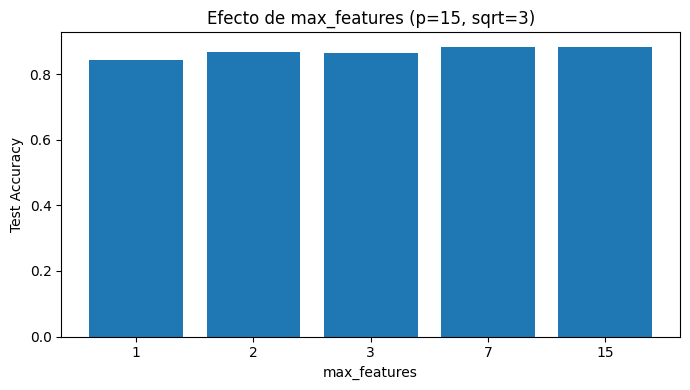

In [15]:
# 6.1 Efecto de max_features
p = X_tr.shape[1]  # número de features
max_features_options = [1, 2, 3, int(np.sqrt(p)), int(np.log2(p)), p//2, p]
labels = [str(v) for v in max_features_options]

mf_accs = []
for mf in max_features_options:
    rf = RandomForestClassifier(
        n_estimators=150, max_features=mf,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    rf.fit(X_tr, y_tr)
    mf_accs.append(accuracy_score(y_te, rf.predict(X_te)))

plt.figure(figsize=(7, 4))
plt.bar(labels, mf_accs)
plt.xlabel("max_features")
plt.ylabel("Test Accuracy")
plt.title(f"Efecto de max_features (p={p}, sqrt={int(np.sqrt(p))})")
plt.tight_layout()
plt.show()

---
## 7) Ejercicios (Semana 8)

### Ejercicio 1 — RF vs árbol: sobreajuste
1. Reporta `Acc_train` y `Acc_test` para el árbol sin restricción y para RF.  
2. ¿Por qué RF no sobreajusta aunque usa árboles sin restricciones?  
3. Explica con la fórmula de varianza del promedio por qué más árboles ayudan.

### Ejercicio 2 — Estabilidad por semillas
1. Repite el experimento de la sección 5 con `n_estimators=10` (pocas árboles).  
2. ¿Aumenta la varianza del RF? ¿Se acerca a la del árbol?  
3. ¿Qué conclusión sacas sobre el mínimo de árboles necesario?

### Ejercicio 3 — OOB score
1. Entrena un RF con `oob_score=True` y compara el OOB score con el test accuracy.  
2. ¿Para qué sirve el OOB? ¿En qué se diferencia de hacer un split train/val?

### Ejercicio 4 — Feature importance
1. Compara el ranking MDI vs Permutation Importance.  
2. ¿Coinciden las top 3 features? Si difieren, ¿cuál de las dos confías más y por qué?

### Ejercicio 5 — `max_features` (conceptual)
1. Si usas `max_features=p` (todas las features), ¿en qué se diferencia RF de un Bagging clásico?  
2. ¿Por qué reducir `max_features` decorrelaciona los árboles y baja la varianza del ensamble?